In [27]:
import getdist.plots as gdplots
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
import cmocean

from getdist import MCSamples, loadMCSamples
from scipy.stats import norm, uniform
from pathlib import Path

import src.analysis.plots as plots

PAPER_FIGURES_ROOT = Path(
    "/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/"
)

pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

### Sources for $S_8$ measurements
-----------------------------------

https://academic.oup.com/mnras/article/505/4/5427/6293862
RSD+BAO+SNIa
- 0.762+0.030-0.025

https://iopscience.iop.org/article/10.3847/1538-4357/acfe06 ACT CMB Lensing
- 0.818\pm0.022 ACT Alone
- 0.813\pm0.018

https://arxiv.org/pdf/1807.06209 Planck Collaboration
- 0.832\pm0.013 TTTEEElowE + lensing
- 0.834\pm0.016 TTTEEElowE
- 0.825\pm0.011 TTTEEElowE + lensing + BAO

https://arxiv.org/abs/2503.19441 KiDS Legacy
- 0.815+0.016-0.021

https://arxiv.org/abs/2007.15633 KiDS 1000
- 0.759+0.024-0.021

https://arxiv.org/abs/2304.00702 HSC Y3 Cosmic Shear (Real)
- 0.769+0.031-0.034

https://arxiv.org/abs/2304.00701 HSC Y3 Cosmic Shear (PS)
- 0.776+0.032-0.033

https://arxiv.org/abs/2507.01386 HSCxSDSS GC-WL
- 0.780+0.029-0.030

https://arxiv.org/abs/1809.09148 HSC Y1 Cosmic Shear
-0.780+0.030_-0.033

https://arxiv.org/abs/2105.13549 DES Y3 3x2pt 
- 0.776+0.017-0.017

https://inspirehep.net/literature/2901636 DES Y3 Cluster Abundances
- 0.864±0.035

https://arxiv.org/abs/2105.03421 WISE Planck CMB Lensing
- 0.784\pm0.015

https://arxiv.org/abs/2504.20038 Unified Planck ACT SPT CMB
- 0.825+0.015-0.013

In [64]:
### S8 constraints compared to other surveys
cmb_s8 = {
    "ACT CMBL": [0.818, (0.022, 0.022)], 
    r"unWISE$\,\times\,$Planck CMBL": [0.784, (0.015, 0.015)],
    r"Planck$\,\times\,$ACT$\,\times\,$SPT CMBL": [0.825, (0.015, 0.013)],
    "Planck TTTEEE" : [0.834, (0.016, 0.016)],
    "Planck TTTEEE + lensing" : [0.832, (0.013, 0.013)],
    "Planck TTTEEE + lensing + BAO" : [0.825, (0.011, 0.011)],
}
other_s8 = {
    "SNIa + RSD + BAO" : [0.762, (0.030, 0.025)], 
    "DES Y3 Cluster Abundances" : [0.864, (0.035, 0.035)], 
}
wl_s8 = {
    "KiDS-Legacy Cosmic Shear": [0.815, (0.016, 0.021)],
    "KiDS-1000 Cosmic Shear": [0.759, (0.024, 0.021)], 
    r"DES-Y3 3$\,\times\,$2pt": [0.776, (0.017, 0.017)],
    "HSC-Y3 Cosmic Shear Real": [0.769, (0.031, 0.034)],
    "HSC-Y3 Cosmic Shear PS": [0.776, (0.032, 0.033)],
    r"HSC-Y3$\,\times\,$SDSS GC-WL": [0.780, (0.029, 0.030)],
    "HSC-Y1 Cosmic Shear": [0.780, (0.030, 0.033)],
}
work_s8 = {
    r"[0.3-3]h$^{−1}$Mpc (pocoMC)" : [0.805, (0.018, 0.018)],
    "Real space, reweighted" : [0.810, (0.018, 0.021)],
    "Power Spectrum, reweighted" : [0.800, (0.029, 0.018)],
}

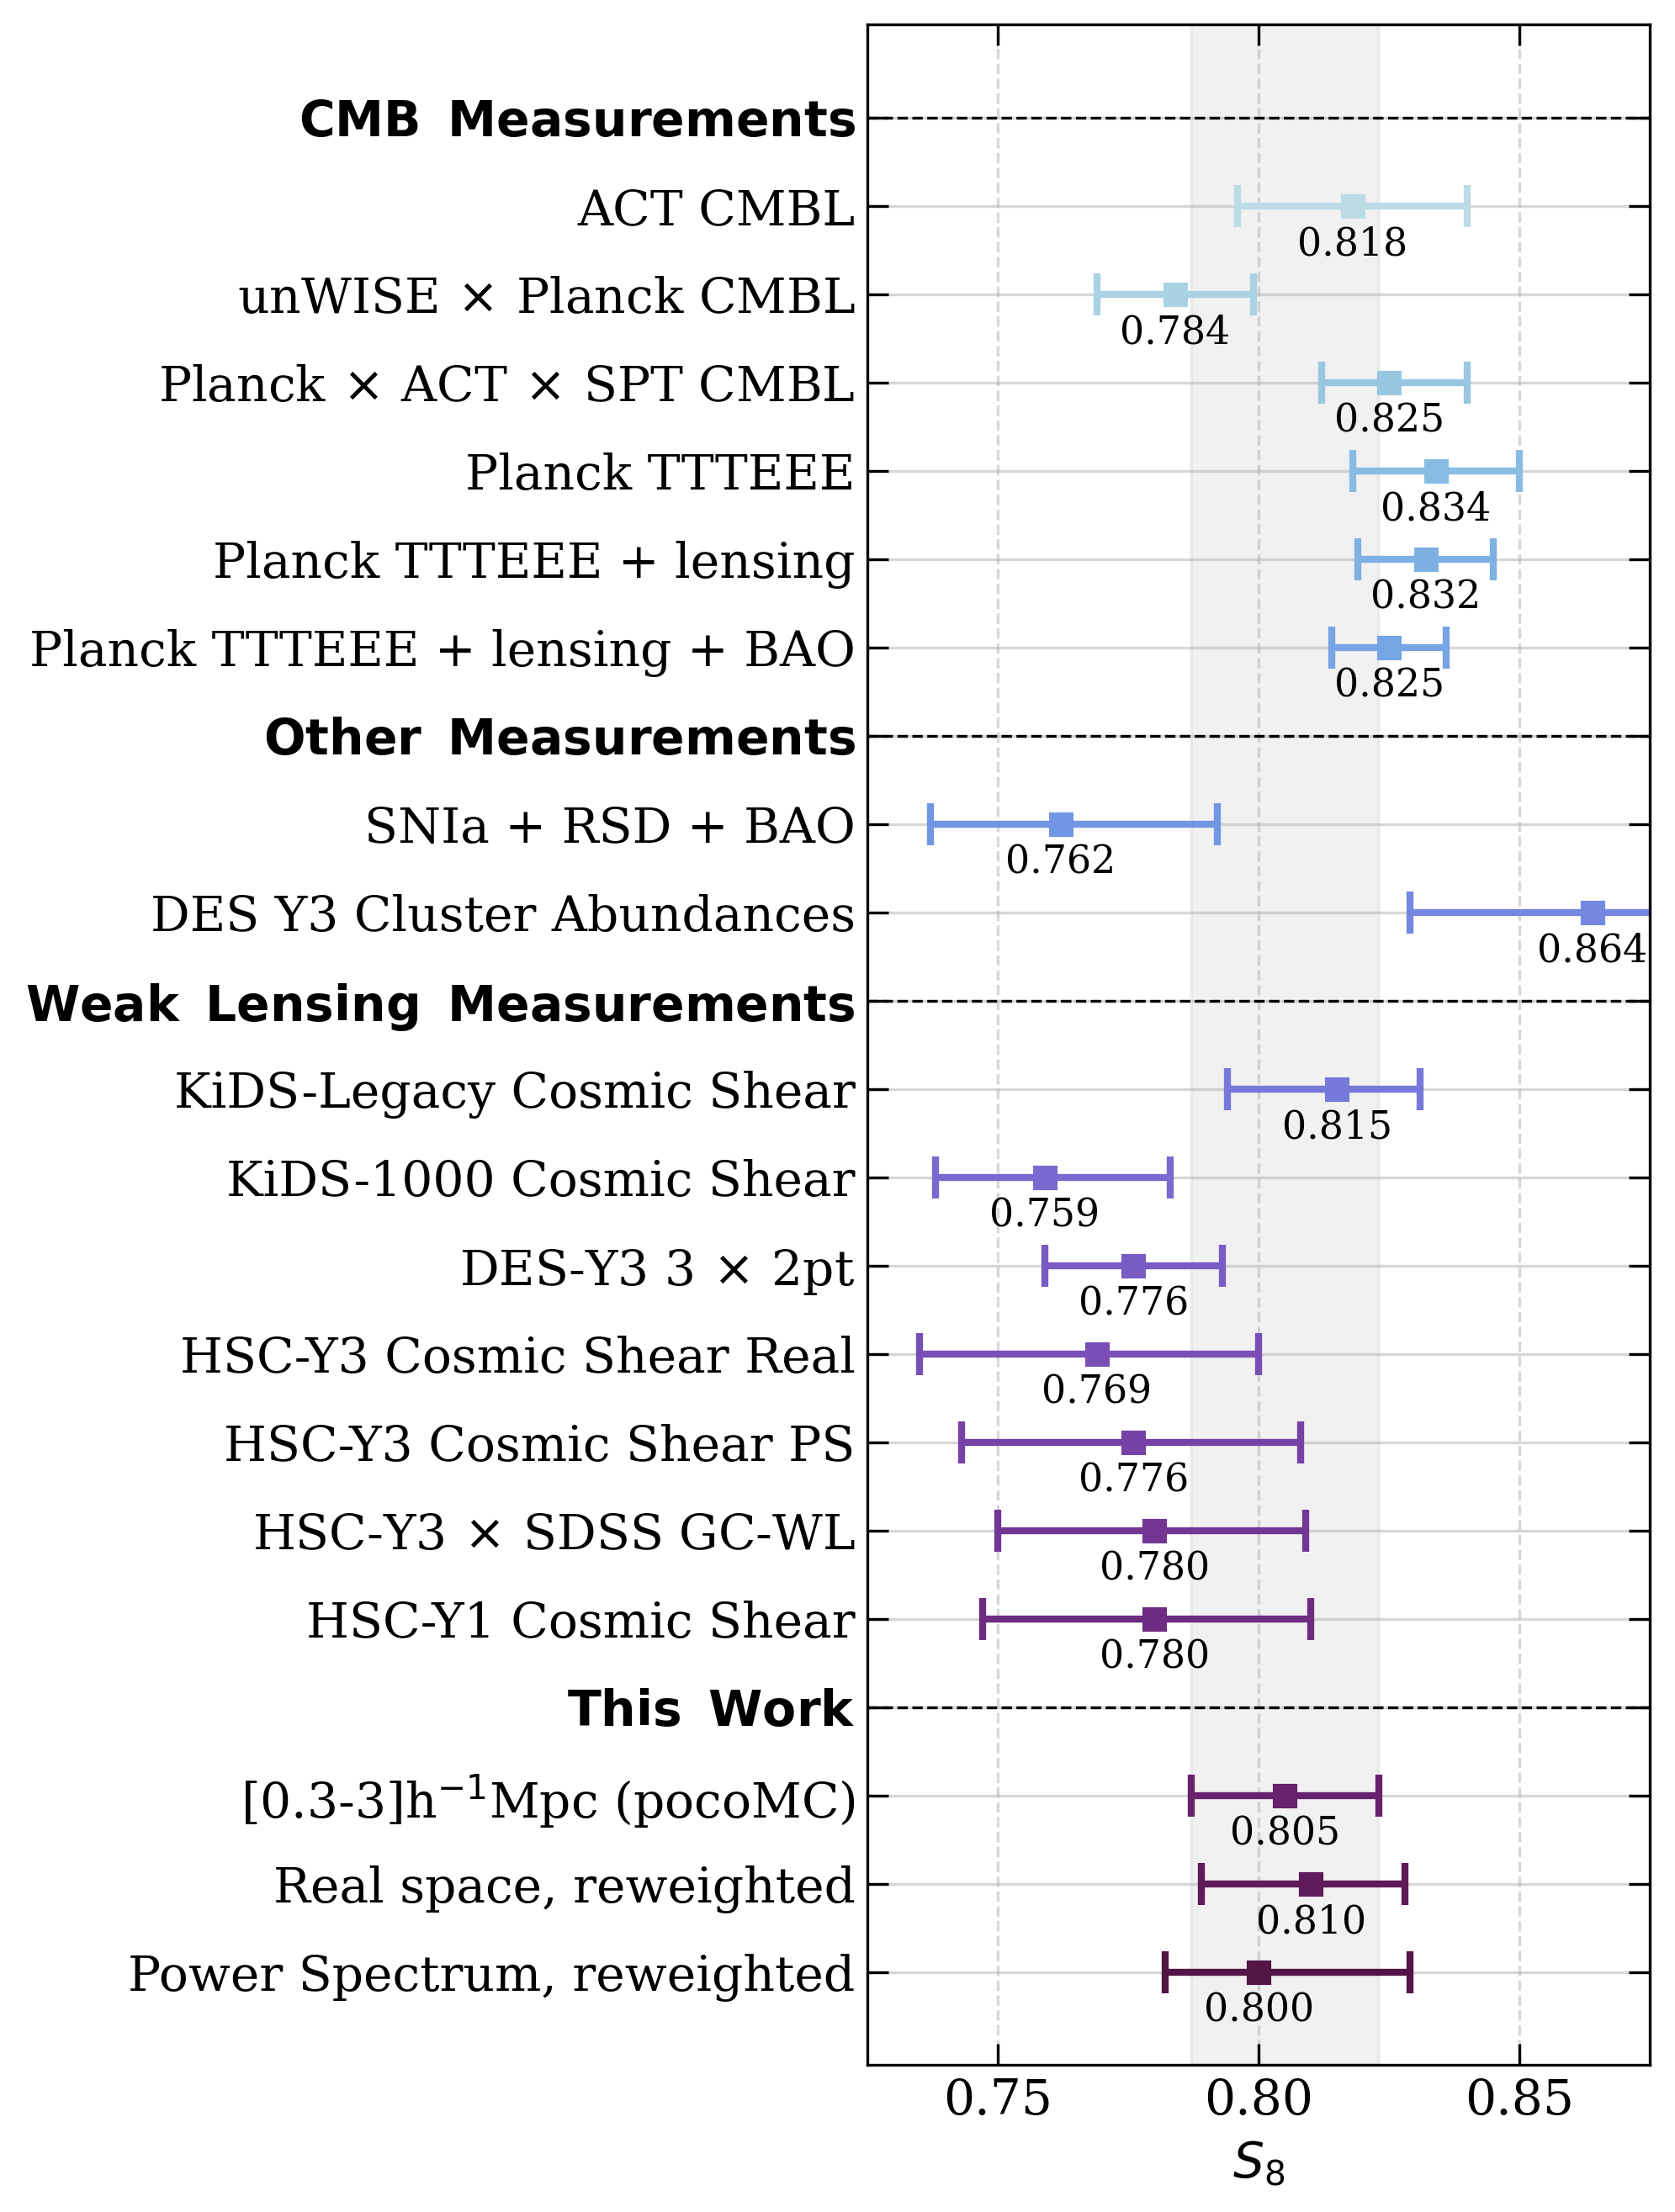

In [66]:
all_dicts = [cmb_s8, other_s8, wl_s8, work_s8]
titles = ["CMB\;\;Measurements", "Other\;\;Measurements", "Weak\;\;Lensing\;\;Measurements", "This\;\;Work"]

all_values = [val for d in all_dicts for val, _ in d.values()]
colors = cmocean.cm.dense(np.linspace(0.1, 0.9, len(all_values))) #ice_r

total_rows = sum(len(d) for d in all_dicts) + (len(all_dicts)-1)

with pm.make_plot("comparison_s8", figsize=(4, total_rows * 0.5), show=True, tight_layout=False) as (fig, ax):

    yticks = []
    ylabels = []
    ypos = 0
    color_idx = 0

    for idx, d in enumerate(all_dicts):

        yticks.append(ypos)
        ylabels.append(f"$\\bf{{{titles[idx]}}}$")
        ax.axhline(ypos, color='black', linestyle='--', linewidth=0.8)

        for key, (val, (err_up, err_down)) in d.items():
            ypos += 1
            ax.errorbar(
                val, ypos,
                xerr=[[err_down], [err_up]],
                fmt='s',
                color=colors[color_idx],
                elinewidth=2,
                markersize=6,
                capsize=6,
                capthick=2
            )
            ax.text(val, ypos + 0.65, f"{val:.3f}", ha='center', va='bottom', fontsize=11)
            yticks.append(ypos)
            ylabels.append(key)
            color_idx += 1
        ypos += 1

    work_val, (work_up, work_down) = work_s8[r"[0.3-3]h$^{−1}$Mpc (pocoMC)"]
    ax.axvspan(work_val - work_down, work_val + work_up, color='lightgray', alpha=0.3, label='This work')

    ax.set_yticks(range(len(ylabels)))
    ax.set_yticklabels(ylabels, fontsize=14)

    ax.invert_yaxis()
    ax.set_xlabel("$S_8$", fontsize=14)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.set_xlim(0.725, 0.875)

In [67]:
def load_and_process_data(filepath, new_priors=None, displace_mean_frompriors=None):
    """Load and process MCMC chain data"""
    with open(filepath, "r") as f:
        header = f.readline().lstrip("#").strip().split()

    df = pd.read_csv(
        filepath, 
        sep='\s+', 
        comment="#", 
        names=header
    )

    if new_priors is not None:
        assert "weight" in df.columns and all(name in df.columns for name in new_priors), "Weights column missing and some prior parameters not in data"
        weights = np.ones(len(df))
        for name in new_priors:
            assert name in df.columns, f'{name} not in columns'
            #old_prior_vals = old_priors[name].pdf(df[name])
            #new_prior_vals = new_priors[name].pdf(df[name])
            mu_i, sigma_i = new_priors[name]
            weights *= np.exp(-(df[name] - mu_i)**2 / (2 * sigma_i**2))
    else:
        weights = np.ones(len(df))
    
    if displace_mean_frompriors is not None:
        for name in displace_mean_frompriors:
            assert name in df.columns, f'{name} not in columns'
            mu_i, sigma_i = displace_mean_frompriors[name]
            current_mean = df[name].mean()
            print(current_mean, mu_i)
            df[name] += (mu_i - current_mean)

    return df, header, np.asarray(weights)

def compute_effective_weights(df, prior_rescale, use_log_weight=False):
    if use_log_weight:
        eff = np.exp(df["log_weight"].values) * prior_rescale
    else:
        eff = df["weight"].values * prior_rescale
    return eff

def make_mc_sample(df, params, param_labels, prior_rescale, label, burn=0.2, use_log_weight=False):
    print(f"Creating MCSamples for {label} with {len(df)} samples, burn={burn}, prior rescale={prior_rescale[:5]}")
    eff = compute_effective_weights(df, prior_rescale, use_log_weight)
    burn_count = int(np.floor(burn * len(df))) if burn>0 else 0
    samples = MCSamples(samples=df[params].values, names=params, labels=param_labels, weights=eff, label=label)
    samples.removeBurn(burn)

    df['post-reweighted'] = df['post'] + np.log(prior_rescale)
    return samples, df.iloc[burn_count:].reset_index(drop=True), eff[burn_count:]

def summarize_chain(samples: MCSamples, out_file: Path):
    """Compute LaTeX-friendly inline summary from MCSamples"""
    with open(out_file, 'a') as f:
        header = f"Summary for {samples.label}\n"
        f.write(header)
        print(header.strip())
        
        for param in samples.paramNames.list():
            line =  samples.getInlineLatex(param)
            f.write(f'{param}: {line}\n')
            print(line)
        f.write("\n")
        
def confidence_interval(x, cdf, level=0.68):
    """Return the lower and upper bounds of a central confidence interval."""
    lower_prob = (1 - level) / 2
    upper_prob = 1 - lower_prob
    lower = np.interp(x=lower_prob, xp=cdf, fp=x)
    upper = np.interp(x=upper_prob, xp=cdf, fp=x)
    return lower, upper

def summarize_samples(dfs_list, samples_list, params, filename, colors, linestyles):
    plt.figure(figsize=(12,4))
    plt.axhline(0, color='black', linestyle='--')
    with open(filename, "w") as f:
        for ins, (df, samples) in enumerate(zip(dfs_list, samples_list)):
            header = f"\n=== {samples.label} ===\n"
            print(header, end="")
            f.write(header)
            
            for p in params:
                max_idx = np.argmax(df["post-reweighted"].values)
                MAP_val = df[p].values[max_idx]
                
                param_density = samples.get1DDensity(p)
                x_sorted = param_density.x
                P_sorted = param_density.P
                prob = P_sorted / np.trapezoid(P_sorted, x_sorted)
                
                mode_idx = np.argmax(prob)
                posterior_mode = param_density.x[mode_idx]
                posterior_mean = np.trapezoid(prob * param_density.x, param_density.x)
                
                dx = np.mean(np.diff(x_sorted))
                param_cdf = np.cumsum(prob * dx) / np.sum(prob * dx)

                ci_68 = confidence_interval(param_density.x, param_cdf, 0.68)
                ci_95 = confidence_interval(param_density.x, param_cdf, 0.95)

                if p == "COSMOLOGICAL_PARAMETERS--S_8":
                    plt.plot(x_sorted, P_sorted, color=colors[ins], label=samples.label + f"{posterior_mode:.3f}^{(posterior_mode - ci_68[0]):.3f}_{(posterior_mode - ci_68[1]):.3f}", linestyle=linestyles[ins])
                    plt.axvline(posterior_mode, color=colors[ins], linestyle=linestyles[ins])
                    plt.axvline(ci_68[0], color=colors[ins], linestyle=linestyles[ins], alpha=0.5)
                    plt.axvline(ci_68[1], color=colors[ins], linestyle=linestyles[ins], alpha=0.5)
                    plt.legend(loc="upper right")
                    plt.title(samples.label)
                    plt.grid()
                    plt.xlabel("S_8")
                    plt.ylabel("Density")
                    plt.xlim(0.65, 0.95)
                    
                line = (
                    f"{p:35s} | Mode: {posterior_mode:.4f}, "
                    f"MAP: {MAP_val:.4f}, "
                    f"Mean: {posterior_mean:.4f} "
                    f"68%-: {ci_68[0]:.4f}, 68%+: {ci_68[1]:.4f}, "
                    f"95%-: {ci_95[0]:.4f}, 95%+: {ci_95[1]:.4f}"
                )
                print(line)
                f.write(line + "\n")

-0.00035372580632403574 0.039
0.0017748602547459722 0.048
0.007324198651492739 0.039
0.0026398642071854953 0.048


/tmp/ipykernel_1969496/3368725059.py:49: RuntimeWarning: divide by zero encountered in log
  df['post-reweighted'] = df['post'] + np.log(prior_rescale)
/tmp/ipykernel_1969496/3368725059.py:49: RuntimeWarning: divide by zero encountered in log
  df['post-reweighted'] = df['post'] + np.log(prior_rescale)


Creating MCSamples for New n(z) PS (pocoMC) with 4482 samples, burn=0.25, prior rescale=[1. 1. 1. 1. 1.]
Removed no burn in
Creating MCSamples for New n(z) Real (pocoMC) with 4385 samples, burn=0.25, prior rescale=[1. 1. 1. 1. 1.]
Removed no burn in
Creating MCSamples for HSC Y3 PS (pocoMC) with 2466 samples, burn=0.25, prior rescale=[1. 1. 1. 1. 1.]
Removed no burn in
Creating MCSamples for HSC Y3 PS (Fiducial) with 10496 samples, burn=0, prior rescale=[1. 1. 1. 1. 1.]
Removed no burn in
Creating MCSamples for HSC Y3 PS (Fiducial, reweighted) with 10496 samples, burn=0, prior rescale=[1.78156759e-045 0.00000000e+000 0.00000000e+000 1.23093707e-060
 6.61532942e-198]
Removed no burn in
Creating MCSamples for HSC Y3 Real (Fiducial) with 12598 samples, burn=0, prior rescale=[1. 1. 1. 1. 1.]
Removed no burn in
Creating MCSamples for HSC Y3 Real (Fiducial, reweighted) with 12598 samples, burn=0, prior rescale=[0.00000000e+000 0.00000000e+000 7.32521768e-110 1.90289278e-192
 0.00000000e+000]

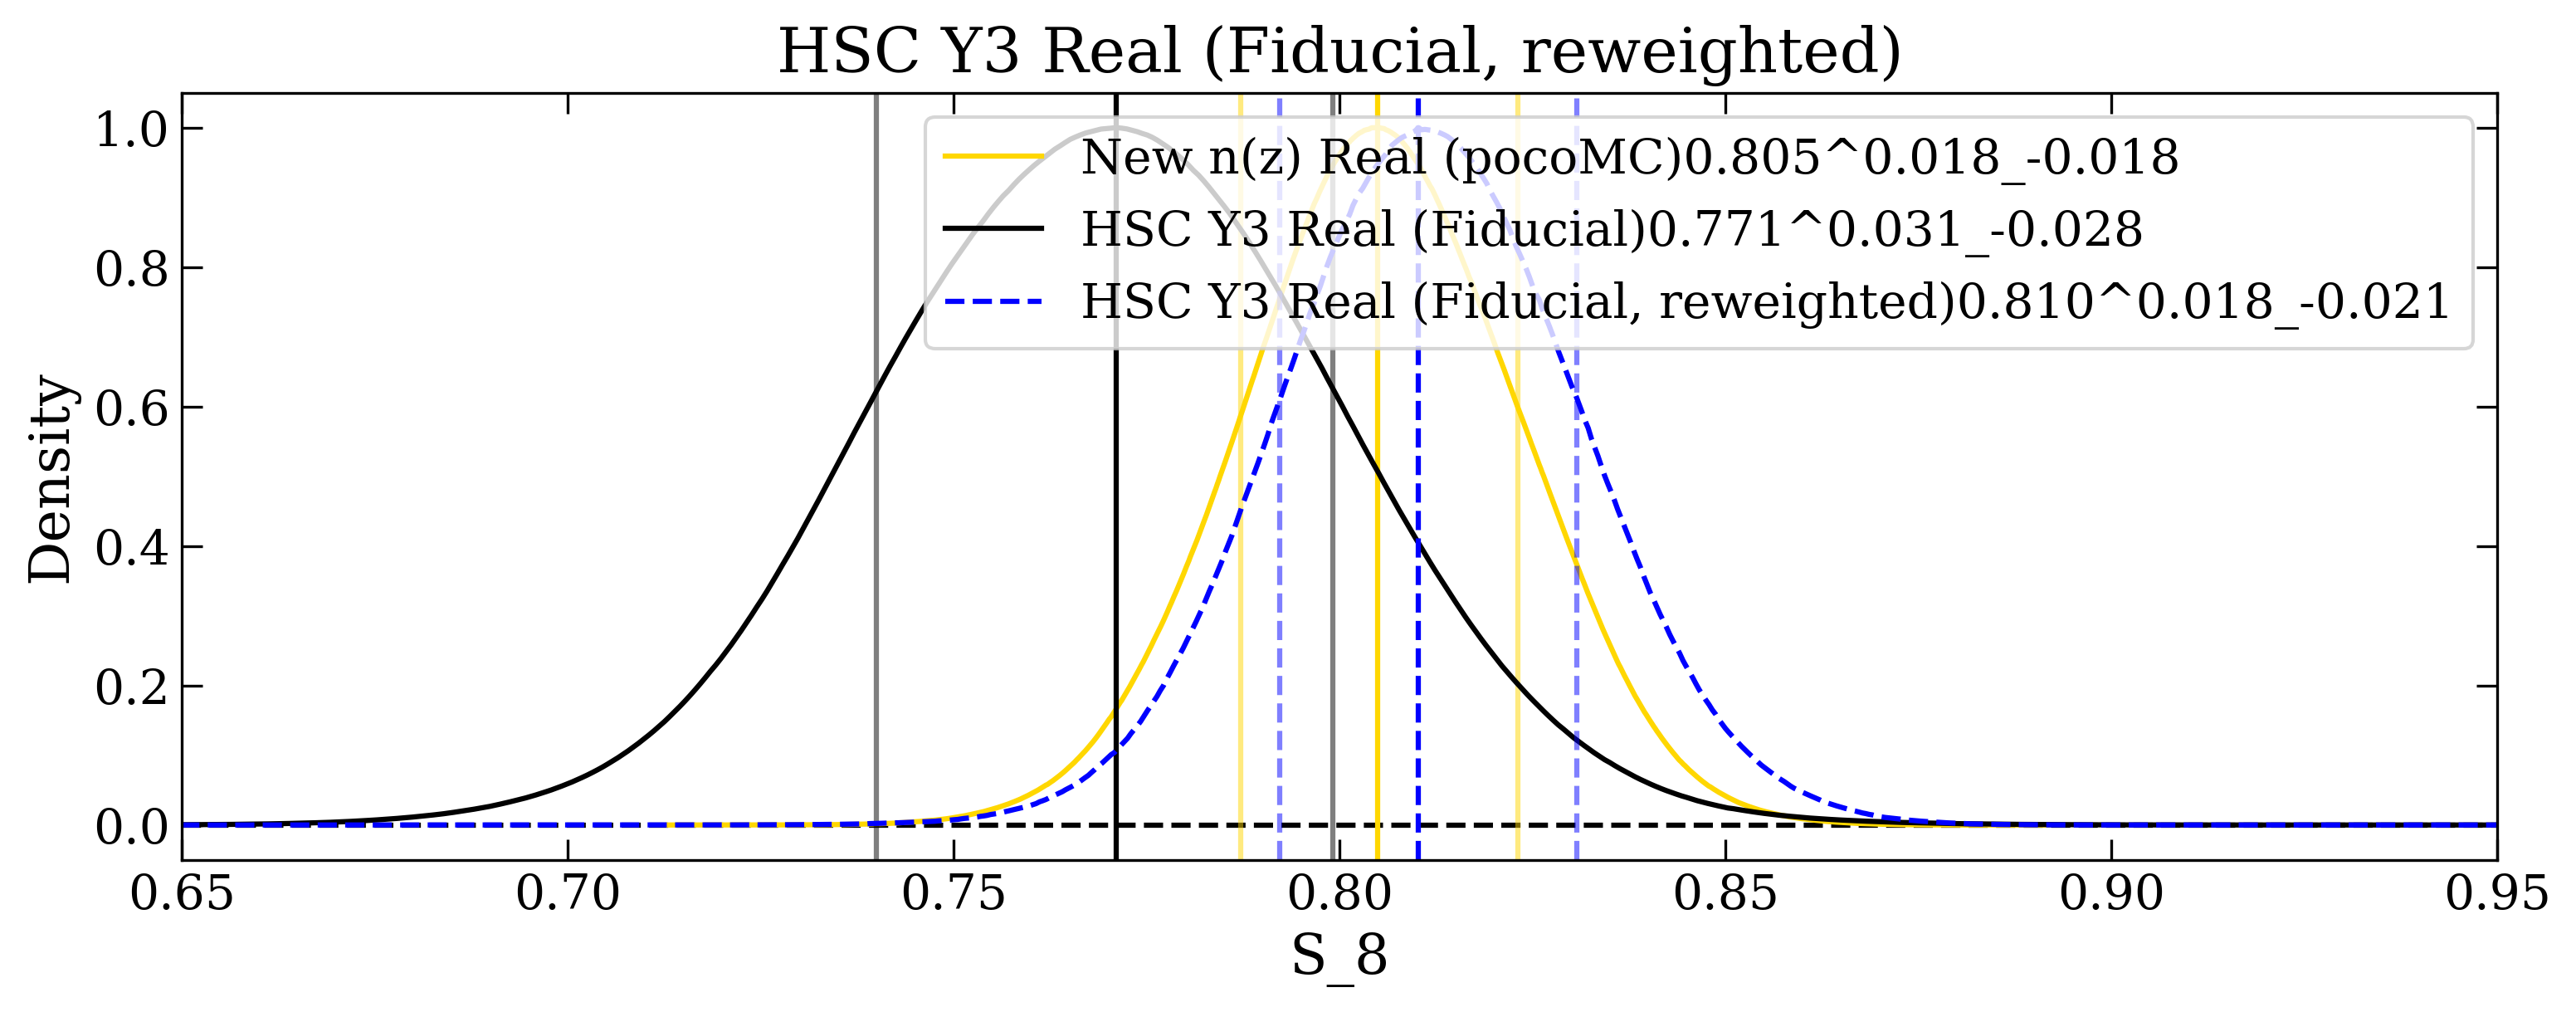

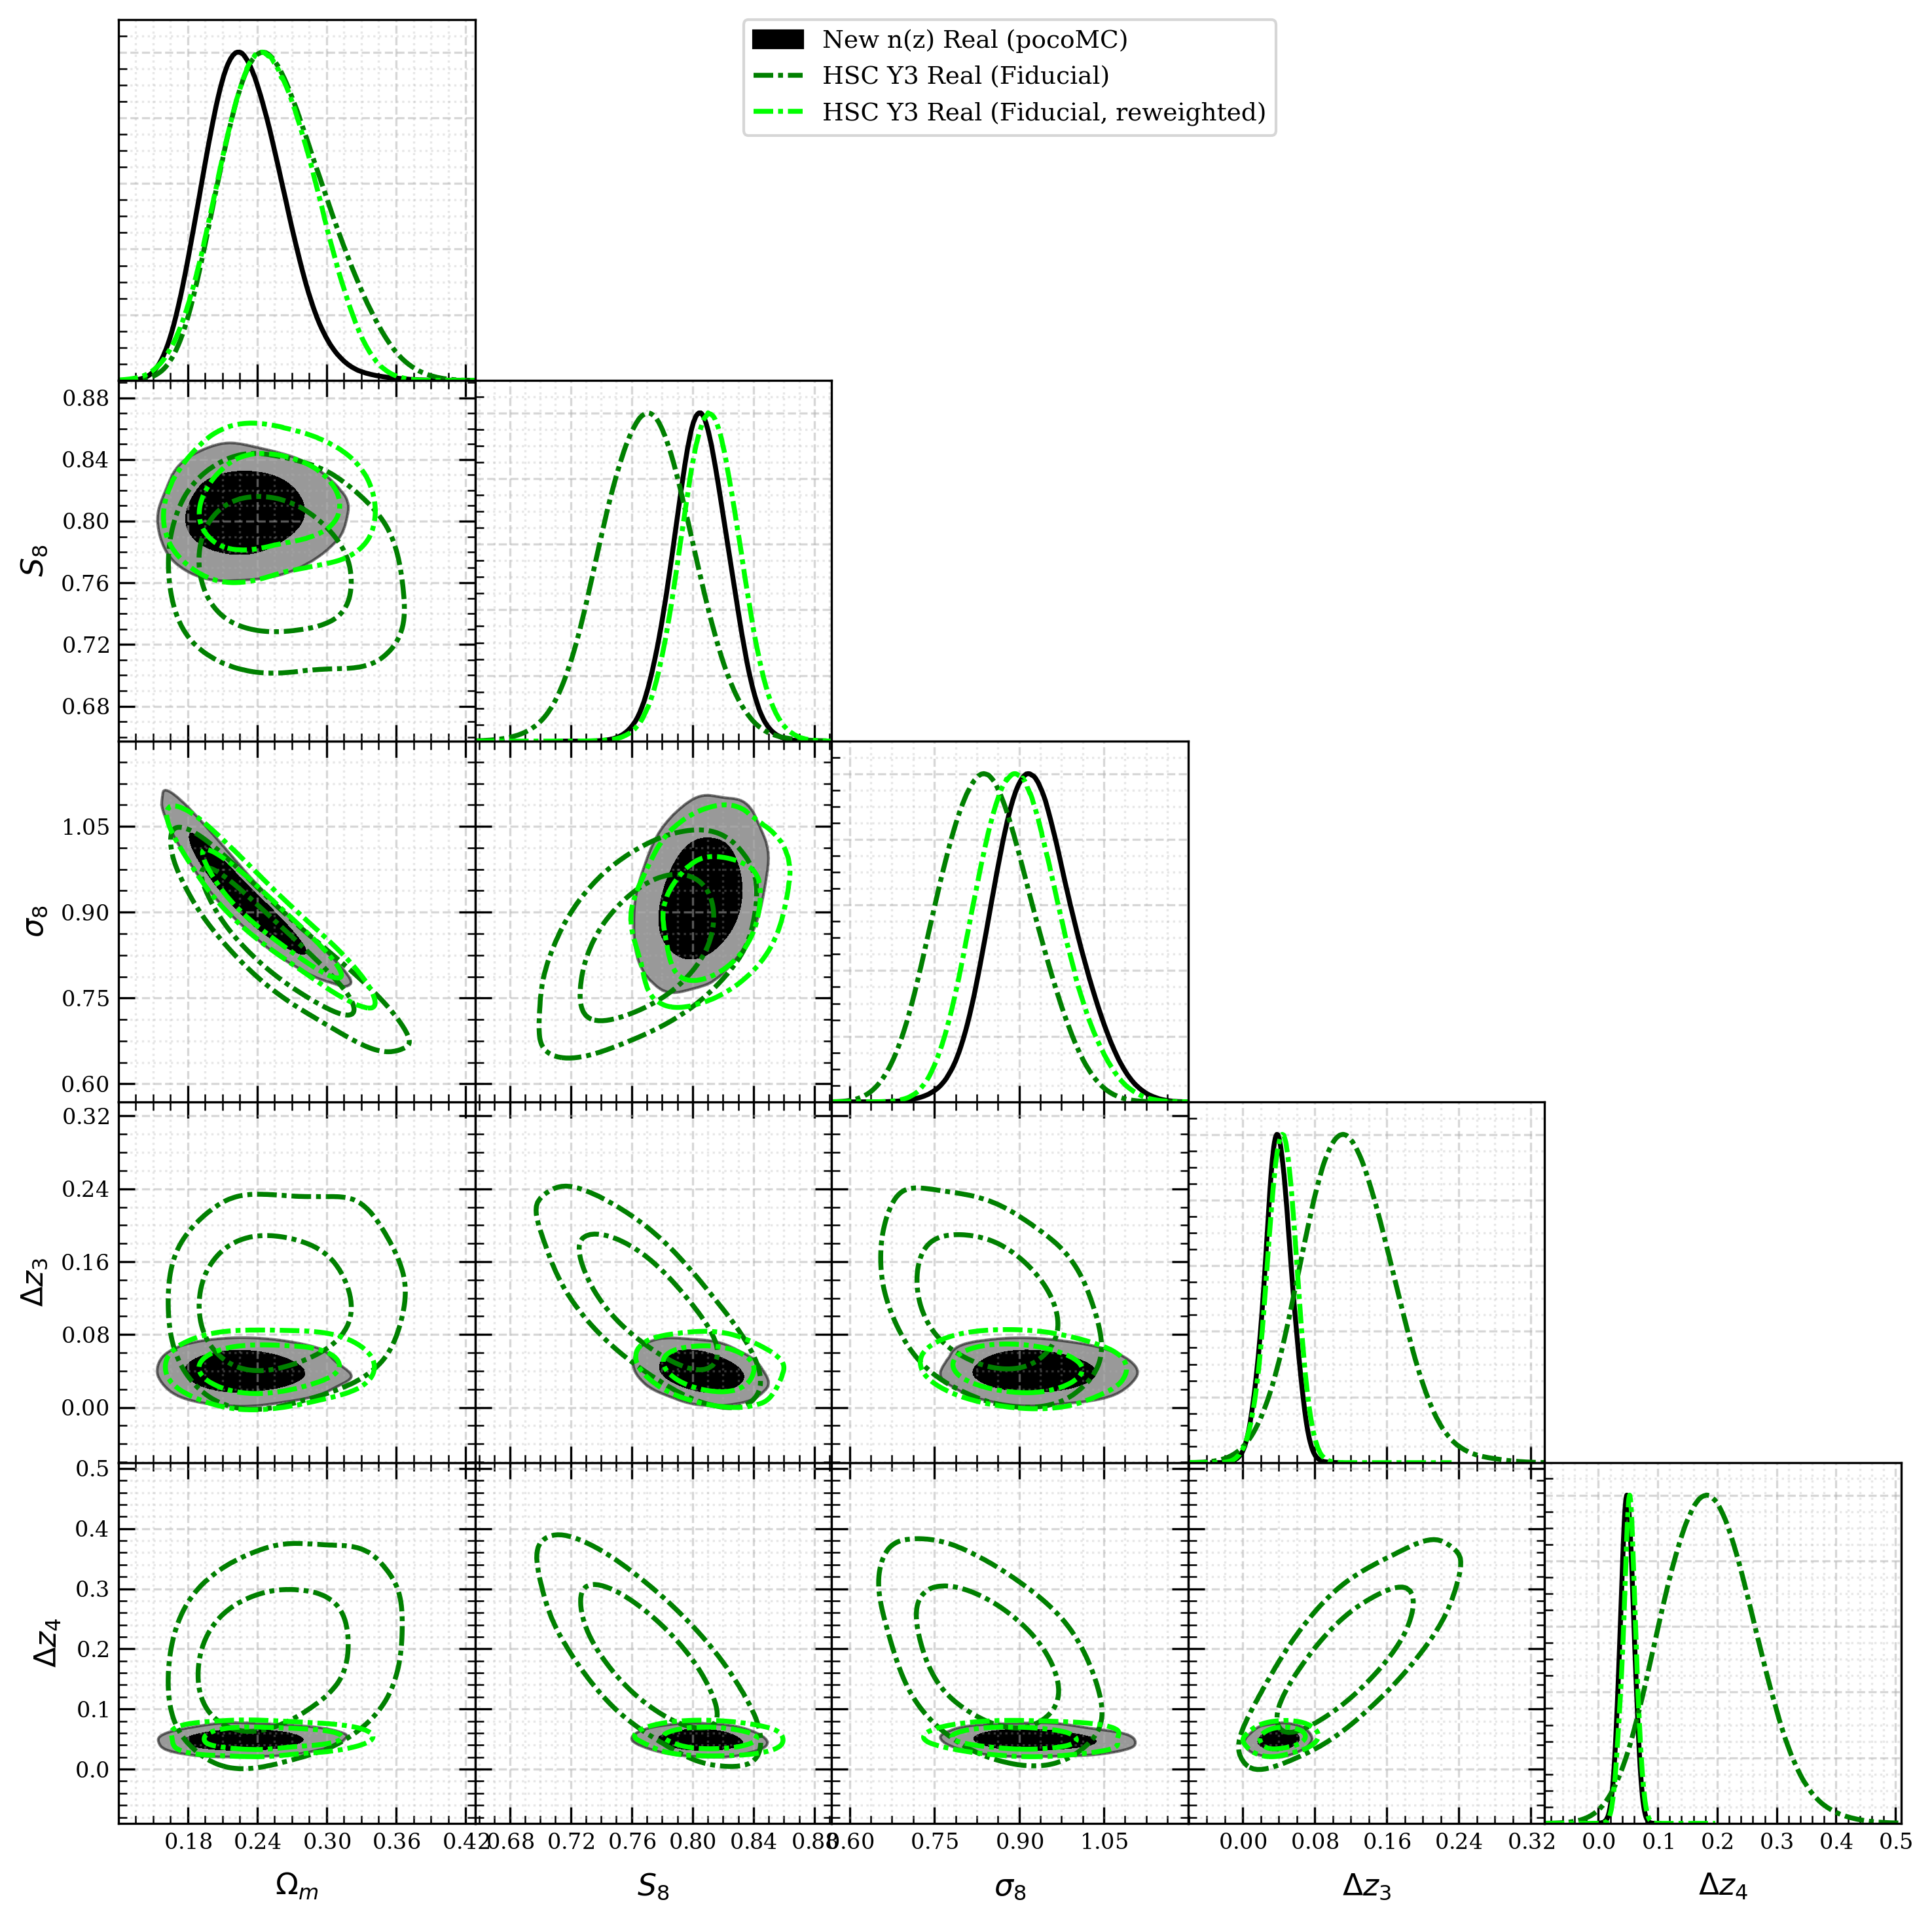

In [68]:
base_dir = Path("/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/cosmic_shear/chains")
ps_splines_file      = base_dir / "out-fourier/hsc-y3-shear.txt"
real_splines_file    = base_dir / "out-corrected-nz-real-28_10_25/hsc-y3-shear.txt"
ps_hscy3             = base_dir / "out-test-fourier/hsc-y3-shear.txt" 
ps_fid               = base_dir / "fiducial-hscy3-fourier/hsc_y3_fourier_cosmic_shear.txt"
real_fid             = base_dir / "fiducial-hscy3-real/polychord_fid.txt"

chain_files = [ps_splines_file, real_splines_file, ps_hscy3, ps_fid, ps_fid, real_fid, real_fid]
labels = [
    "New n(z) PS (pocoMC)", 
    "New n(z) Real (pocoMC)",
    "HSC Y3 PS (pocoMC)", 
    "HSC Y3 PS (Fiducial)",
    "HSC Y3 PS (Fiducial, reweighted)", 
    "HSC Y3 Real (Fiducial)", 
    "HSC Y3 Real (Fiducial, reweighted)",
]
priors = {
    #'wl_photoz_errors--bias_1': norm(loc=-0.026, scale=0.009),
    #'wl_photoz_errors--bias_2': norm(loc=-0.010, scale=0.007),
    'wl_photoz_errors--bias_3': (0.039, 0.020),
    'wl_photoz_errors--bias_4': (0.048, 0.012),
}
old_priors = {
    'wl_photoz_errors--bias_1': norm(0, scale=0.024),
    'wl_photoz_errors--bias_2': norm(0, scale=0.022),
    'wl_photoz_errors--bias_3': uniform(loc=-1, scale=2.0),
    'wl_photoz_errors--bias_4': uniform(loc=-1, scale=2.0),
}
params = [
    "cosmological_parameters--omega_m",
    "COSMOLOGICAL_PARAMETERS--S_8",
    "COSMOLOGICAL_PARAMETERS--SIGMA_8",
    #'wl_photoz_errors--bias_1',
    #'wl_photoz_errors--bias_2',
    #'halo_model_parameters--a_bary',
    'wl_photoz_errors--bias_3',
    'wl_photoz_errors--bias_4'
    #'halo_model_parameters--a_bary',
    #"intrinsic_alignment_parameters--a1",
    #"intrinsic_alignment_parameters--a2",
    #"intrinsic_alignment_parameters--alpha1",
    #"intrinsic_alignment_parameters--alpha2",
    #"intrinsic_alignment_parameters--bias_ta"
]
param_labels = [r"\Omega_m", r"S_8", r"\sigma_8", r"\Delta z_3", r"\Delta z_4"]
                #r"A_{bary}", r"A_{1}^{IA}", r"A_{2}^{IA}", r"\alpha_{1}^{IA}", r"\alpha_{2}^{IA}", r"b_{TA}^{IA}"]
base_burn = 0.25
priors_list = [None, None, None, None, priors, None, priors]
old_priors_list = [None, None, None, None, old_priors, None, old_priors]

df1, header1, prior_rescale1 = load_and_process_data(ps_splines_file, displace_mean_frompriors=priors)
df2, header2, prior_rescale2 = load_and_process_data(real_splines_file, displace_mean_frompriors=priors)
df3, header3, prior_rescale3 = load_and_process_data(ps_hscy3)
df4, header4, prior_rescale4 = load_and_process_data(ps_fid) 
df5, header5, prior_rescale5 = load_and_process_data(ps_fid, new_priors=priors)
df6, header6, prior_rescale6 = load_and_process_data(real_fid)
df7, header7, prior_rescale7 = load_and_process_data(real_fid, new_priors=priors)

samples1, ndf1, w1 = make_mc_sample(df1, params, param_labels, prior_rescale1, "New n(z) PS (pocoMC)", burn=base_burn, use_log_weight=True)
samples2, ndf2, w2 = make_mc_sample(df2, params, param_labels, prior_rescale2, "New n(z) Real (pocoMC)", burn=base_burn, use_log_weight=True)
samples3, ndf3, w3 = make_mc_sample(df3, params, param_labels, prior_rescale3, "HSC Y3 PS (pocoMC)", burn=base_burn, use_log_weight=True)
samples4, ndf4, w4 = make_mc_sample(df4, params, param_labels, prior_rescale4, "HSC Y3 PS (Fiducial)", burn=0)
samples5, ndf5, w5 = make_mc_sample(df5, params, param_labels, prior_rescale5, "HSC Y3 PS (Fiducial, reweighted)", burn=0)
samples6, ndf6, w6 = make_mc_sample(df6, params, param_labels, prior_rescale6, "HSC Y3 Real (Fiducial)", burn=0)
samples7, ndf7, w7 = make_mc_sample(df7, params, param_labels, prior_rescale7, "HSC Y3 Real (Fiducial, reweighted)", burn=0)

samples_list = [samples1, samples2, samples3, samples4, samples5, samples6, samples7]

colors = ["gold", "black", "blue", "cyan", "red", "green", "lime"]
linestyles = ["-", "-", "--", "--", "-", "-.", "-."]
filled = [True, True, False, False, False, False, False]

assert len(colors) == len(linestyles) == len(filled) == len(samples_list)
assert len(params) == len(param_labels)

out_summary = Path("summaries/summary.txt")
out_summary.parent.mkdir(exist_ok=True)
if out_summary.exists(): 
    out_summary.unlink() 
    
def do_mask(data, mask):
    return [d for d, m in zip(data, mask) if m]
mask = [False, True, False, False, False, True, True]
summarize_samples(
    dfs_list=do_mask([ndf1, ndf2, ndf3, ndf4, ndf5, ndf6, ndf7], mask),
    samples_list=do_mask([samples1, samples2, samples3, samples4, samples5, samples6, samples7], mask),
    params=params,
    filename=out_summary,
    colors=colors,
    linestyles=linestyles
)

print(f"\nPosterior summary also saved to {out_summary}")

g = gdplots.get_subplot_plotter()
g.triangle_plot(
    do_mask(samples_list, mask),
    params, 
    filled=do_mask(filled, mask),
    line_args=[{"color": c, "ls": ls, "lw": 1.8} for c, ls in zip(do_mask(colors, mask), do_mask(linestyles, mask))],
    contour_colors=do_mask(colors, mask), 
    contour_ls=do_mask(linestyles, mask), 
    contour_lws=[1.8]*np.sum(mask)
    )

for ax in g.subplots.flatten():
    if ax:
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6))
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.grid(which='minor', linestyle=':', alpha=0.3)

plt.show()